In [1]:
from include import *

In [2]:
fashion_active_sim = np.load(savePath / 'fashion_active_sim.npy', allow_pickle=True)
fashion_active_exp = np.load(savePath / 'fashion_active_exp.npy', allow_pickle=True)
fashion_direct_imaging = np.load(savePath / 'fashion_directimg.npy', allow_pickle=True)
fashion_nonPA_e2e = np.load(savePath / 'fashion_nonpae2e.npy', allow_pickle=True)

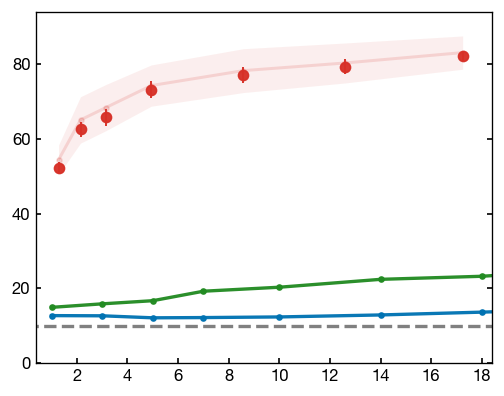

In [3]:
common_kwg = {'capsize':0,'alpha':0.96,'ms':6}
fig, ax = plt.subplots(figsize=(4.3,3.4),dpi=120)

exp_pans = fashion_active_exp[fashion_active_sim['K'] == 1].sort_values('N')
sim_pans = fashion_active_sim[fashion_active_exp['K'] == 1].sort_values('N')
nstd = 3 

 
ax.errorbar(exp_pans['det_photon_count'],exp_pans['mean_accuracy'],yerr=exp_pans['std_dev'],fmt='o',c=c_red,label='Experiment: active PANS',**common_kwg,zorder=100)
ax.errorbar(exp_pans['det_photon_count'],sim_pans['mean_accuracy'],fmt='.-',lw=1.8,color=c_red,alpha=0.15,label='Simulation: active PANS')
ax.fill_between(exp_pans['det_photon_count'],(sim_pans['mean_accuracy']+sim_pans['std_dev']*nstd),(sim_pans['mean_accuracy']-sim_pans['std_dev']*nstd),color=c_red,alpha=0.08,lw=0)

ax.errorbar(fashion_nonPA_e2e['det_photon_count'], fashion_nonPA_e2e['accuracy'],\
            lw=2,label='Simulation: non-PA E2E',fmt='.-',c=c_green, **common_kwg)
ax.errorbar(fashion_direct_imaging['det_photon_count'], fashion_direct_imaging['accuracy'],\
            lw=2,label='Simulation: direct imaging',fmt='.-',c=c_blue,**common_kwg)
ax.plot([0,20],[10,10],'--',lw=2,c='grey')

ax.set_ylim(0,94)
ax.set_xlim(0.4,18.4)
plt.tight_layout()
plt.savefig(plotPath / 'Fig2_fashion_Ndet.png')

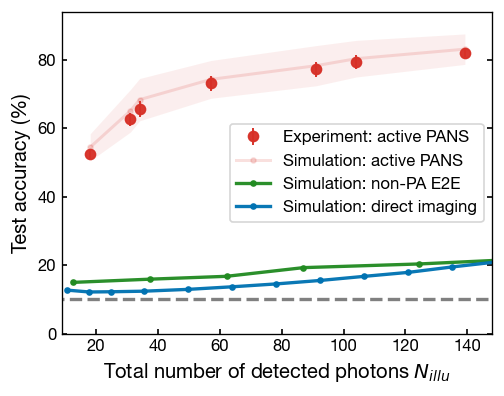

In [4]:
common_kwg = {'capsize':0,'alpha':0.96,'ms':6}
fig, ax = plt.subplots(figsize=(4.3,3.4),dpi=120)

exp_sel = fashion_active_exp[fashion_active_sim['K'] == 1].sort_values('N')
sim_sel = fashion_active_sim[fashion_active_exp['K'] == 1].sort_values('N')
nstd = 3 

plt.xlabel(r'Total number of detected photons $N_{illu}$')
plt.ylabel('Test accuracy (%)')

ax.errorbar(exp_sel['illum_photon_count'],exp_sel['mean_accuracy'],yerr=exp_sel['std_dev'],fmt='o',c=c_red,label='Experiment: active PANS',**common_kwg,zorder=100)
ax.errorbar(exp_sel['illum_photon_count'],sim_sel['mean_accuracy'],fmt='.-',lw=1.8,color=c_red,alpha=0.15,label='Simulation: active PANS')
ax.fill_between(exp_sel['illum_photon_count'],(sim_sel['mean_accuracy']+sim_sel['std_dev']*nstd),(sim_sel['mean_accuracy']-sim_sel['std_dev']*nstd),color=c_red,alpha=0.08,lw=0)

ax.errorbar(fashion_nonPA_e2e['illum_photon_count'], fashion_nonPA_e2e['accuracy'],\
            lw=2,label='Simulation: non-PA E2E',fmt='.-',c=c_green, **common_kwg)
ax.errorbar(fashion_direct_imaging['illum_photon_count'][1:], fashion_direct_imaging['accuracy'][1:],\
            lw=2,label='Simulation: direct imaging',fmt='.-',c=c_blue,**common_kwg)
ax.plot([0,200],[10,10],'--',lw=2,c='grey')

ax.set_ylim(0,94)
ax.set_xlim(9,148)
plt.legend()
plt.tight_layout()
plt.savefig(plotPath / 'Fig2_fashion_Nillu.png')